# Baseline Logistic Regression Model

# Baseline Model: Logistic Regression

## Motivation

Before evaluating more complex models such as autoencoders, we establish a **supervised baseline classifier** using Logistic Regression. This model provides a strong statistical reference point because it is:

- Interpretable
- Computationally efficient
- Well-understood theoretically
- A standard benchmark for tabular classification problems

The purpose of this baseline is to measure how well a classical linear model can distinguish between **normal** and **attack** network traffic in the RT-IoT 2022 dataset.

## Model Formulation

Logistic Regression models the probability that an observation belongs to the attack class given a feature vector $x \in \mathbb{R}^d$. The model assumes a linear relationship between features and the log-odds of the outcome:

$$
P(y = 1 \mid x) = \sigma(w^\top x + b)
$$

where

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

is the sigmoid function, \(w\) represents model coefficients, and \(b\) is the intercept.

Equivalently, Logistic Regression models the log-odds (logit) as a linear function:

$$
\log \frac{P(y=1 \mid x)}{P(y=0 \mid x)} = w^\top x + b
$$

## Optimization Objective

Model parameters are learned by minimizing the **regularized negative log-likelihood** (logistic loss):

$$
\mathcal{L}(w,b)
=
-\frac{1}{n}
\sum_{i=1}^{n}
\left[
y_i \log(p_i) + (1-y_i)\log(1-p_i)
\right]
+ \lambda \|w\|_2^2
$$

where

$$
p_i = \sigma(w^\top x_i + b)
$$

and $\lambda \|w\|_2^2$ represents L2 regularization, which discourages excessively large coefficients and improves generalization.

The optimization is solved numerically using gradient-based methods (LBFGS in scikit-learn).

## Implementation

The baseline model is implemented using scikit-learn’s `Pipeline`, which integrates preprocessing and classification into a single reproducible workflow. All preprocessing steps are learned exclusively from the training data within each cross-validation fold, preventing information leakage during model evaluation.

The pipeline consists of the following components:

- **Categorical encoding:** the `proto` and `service` variables are transformed using **one-hot encoding**, converting categorical network descriptors into mutually exclusive binary indicator features. The encoder is fit only on the training split, ensuring consistent feature mappings and safe handling of unseen categories during evaluation.

- **Log transformation of skewed features:** numeric predictors exhibiting strong distributional asymmetry (**absolute skewness greater than 2.0**, identified during exploratory analysis) are transformed using the $\log(1+x)$ function. This variance-stabilizing transformation reduces heavy-tailed behavior common in network traffic statistics and mitigates the influence of extreme flow values on model estimation.

- **Feature standardization:** following transformation, all numeric features are standardized using `StandardScaler`. Scaling ensures comparable feature magnitudes and improves numerical stability during optimization.

- **Logistic Regression classifier:** a regularized Logistic Regression model (`solver="lbfgs"`) estimates class probabilities using an **L2 penalty** to control coefficient magnitude and improve generalization. 

Encapsulating encoding, transformation, scaling, and classification within a single pipeline guarantees that preprocessing is recomputed independently for each cross-validation split. This produces leak-free out-of-fold predictions while maintaining identical preprocessing during training and testing. Using a unified pipeline also enables **fair comparison with subsequent models** by enforcing a consistent experimental framework across experiments. Consequently, observed performance differences reflect modeling choices rather than inconsistencies in data preparation.

## Evaluation:

After training the Logistic Regression model and calibrating the decision threshold using out-of-fold predictions on the training data, we perform a **single final evaluation** on the held-out test set. This step provides an unbiased estimate of real-world performance because:

- The model was trained only on training data.
- The classification threshold was tuned using cross-validation.
- The test set remains completely unseen until this stage.

This separation prevents information leakage and ensures statistically valid evaluation.

## Logistic Regression Baseline: Key Findings (WORKING)

@tbl-rtiot-lr-cv-summary
@tbl-rtiot-lr-test-eval
@tbl-rtiot-lr-confusion-matrix
@fig-rtiot-lr-roc
@tbl-rtiot-lr-coefs

In [ ]:
# Identify categorical columns from TRAIN only
categorical_cols = X_train.select_dtypes(
    include=["object", "string"]
).columns.tolist()

# Identify numeric columns from TRAIN only
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

Xtr_num = X_train[numeric_cols]
Xte_num = X_test[numeric_cols]

# Identify constant numeric columns (zero variance) from TRAIN only
const_cols = Xtr_num.columns[Xtr_num.nunique(dropna=False) <= 1].tolist()
keep_cols = [c for c in numeric_cols if c not in const_cols]

# Final numeric datasets after dropping constant columns
Xp_train_num = Xtr_num[keep_cols].copy()
Xp_test_num  = Xte_num[keep_cols].copy()

# Fit encoder ONLY on training data
ohe = OneHotEncoder(
    handle_unknown="ignore",   # critical for test safety
    sparse_output=False
)

# Transform both train and test
Xtr_cat = ohe.fit_transform(X_train[categorical_cols])
Xte_cat = ohe.transform(X_test[categorical_cols])

# Get feature names for the one-hot encoded columns
cat_feature_names = ohe.get_feature_names_out(categorical_cols)

# Convert back to DataFrame for easier concatenation and indexing
Xtr_cat = pd.DataFrame(
    Xtr_cat,
    columns=cat_feature_names,
    index=X_train.index
)

Xte_cat = pd.DataFrame(
    Xte_cat,
    columns=cat_feature_names,
    index=X_test.index
)

# Concatenate numeric and categorical features back together
Xp_train = pd.concat([Xp_train_num, Xtr_cat], axis=1)
Xp_test  = pd.concat([Xp_test_num,  Xte_cat], axis=1)



In [ ]:
# Define log transformer for skewed features
log_transformer = FunctionTransformer(
    np.log1p,
    validate=False
)

# Define column transformer for preprocessing
LOG_COLS = SKEWED_FEATURES

OTHER_NUM_COLS = [
    c for c in Xp_train.columns
    if c not in LOG_COLS
]

# Pipeline that applies log transform + scaling to skewed features, and scaling only to the rest of the numeric features
preprocess = ColumnTransformer(
    transformers=[
        ("log_scale", Pipeline([
            ("log", log_transformer),
            ("scaler", StandardScaler())
        ]), LOG_COLS),

        ("scale_only", StandardScaler(), OTHER_NUM_COLS),
    ],
    remainder="drop"
)

In [ ]:
# Build pipeline
pipe = Pipeline([
    ("preprocess", preprocess),
    ("clf", LogisticRegression(
        C=1.0,
        l1_ratio=0.0,          # L2 regularization
        solver="lbfgs",
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

In [ ]:
#| label: tbl-rtiot-lr-cv-summary
#| tbl-cap: "Logistic Regression Cross-Validation Summary showing best threshold and corresponding F1 score on out-of-fold predictions (train-only)."
#| echo: false
#| tbl-pos: H

# OOF probabilities (train only) 
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state= RANDOM_STATE
                     )
oof_score = cross_val_predict(
    pipe,
    Xp_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]  # P(attack | x)

# Tune threshold on OOF scores
best_thr, best_oof_f1 = tune_threshold_max_f1_attack(
    np.asarray(y_train).ravel(), oof_score
)

# Show CV threshold summary
cv_summary = pd.DataFrame([{
    "best_threshold": float(best_thr),
    "best_oof_f1_attack": float(best_oof_f1),
    "cv_folds": cv.get_n_splits()
}])
show_table(cv_summary)

,best_threshold,best_oof_f1_attack,cv_folds
0,0.458,0.994481,5


In [ ]:
#| label: tbl-rtiot-lr-test-eval
#| tbl-cap: "Test set evaluation metrics for Logistic Regression baseline at tuned threshold from train-only cross-validation."
#| echo: false
#| tbl-pos: H

# Fit final model on full training set
pipe.fit(Xp_train, np.asarray(y_train).ravel())

# Test probabilities + evaluation
test_score = pipe.predict_proba(Xp_test)[:, 1]  # P(attack | x)

# Ensure numpy arrays for metrics function
y_test_np = np.asarray(y_test).ravel()

# Flatten test_score if it's not already 1D
test_score = np.asarray(test_score).ravel()

# Evaluate using tuned threshold from OOF tuning
metrics = evaluate_scores(
    y_true=y_test_np,
    y_score=test_score,
    threshold=float(best_thr),
)

# Display as vertical key/value table
metrics_df = as_table(metrics).T.rename(columns={0: "value"})
show_table(metrics_df)

,value
threshold,0.458000
precision_attack,0.993347
recall_attack,0.994174
f1_attack,0.993760
f1_macro,0.993758
roc_auc,0.999260
pr_auc,0.999204
tn,2387.000000
fp,16.000000
fn,14.000000


In [ ]:
#| label: tbl-rtiot-lr-confusion-matrix
#| tbl-cap: "Confusion Matrix for Logistic Regression at tuned threshold."
#| echo: false
#| tbl-pos: H

# Show confusion matrix
y_pred = (test_score >= float(best_thr)).astype(int)
cm = pd.DataFrame(
    [[np.sum((y_test_np == 0) & (y_pred == 0)), np.sum((y_test_np == 0) & (y_pred == 1))],
     [np.sum((y_test_np == 1) & (y_pred == 0)), np.sum((y_test_np == 1) & (y_pred == 1))]],
    index=["true_normal(0)", "true_attack(1)"],
    columns=["pred_normal(0)", "pred_attack(1)"],
)
show_table(cm)

,pred_normal(0),pred_attack(1)
true_normal(0),2387,16
true_attack(1),14,2389


ROC curve (test set)


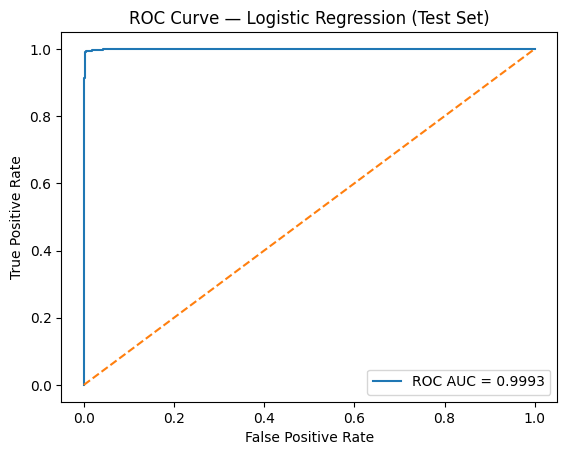

In [ ]:
#| label: fig-rtiot-lr-roc
#| fig-cap: "ROC curve for Logistic Regression on test set, showing AUC score."
#| fig-width: 8
#| fig-height: 6
#| echo: false

print("ROC curve (test set)")

fpr, tpr, _ = roc_curve(y_test.to_numpy(), test_score)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--") 
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Logistic Regression (Test Set)")
plt.legend(loc="lower right")
plt.show()


In [ ]:
#| label: tbl-rtiot-lr-coefs
#| tbl-cap: "Top 8 features by absolute coefficient magnitude from Logistic Regression model, indicating their relative importance for attack detection."
#| echo: false
#| tbl-pos: H

# Extract absolute coefficient magnitudes
coefs = np.abs(pipe.named_steps["clf"].coef_.ravel())

# Build Logistic Regression importance table
lr_importance = (
    pd.DataFrame({
        "feature": Xp_train.columns,
        "abs_coefficient": coefs
    })
    .sort_values("abs_coefficient", ascending=False)
    .head(20)
    .reset_index(drop=True)
)

show_table(lr_importance)

,feature,abs_coefficient
0,flow_ACK_flag_count,3.920119
1,service_mqtt,3.864157
2,fwd_header_size_max,2.618150
3,bwd_subflow_pkts,2.326884
4,flow_ECE_flag_count,2.294272
5,bwd_pkts_payload.max,2.281785
6,fwd_init_window_size,2.264444
7,fwd_subflow_bytes,2.187293
8,fwd_iat.tot,2.105937
9,active.std,2.050897
